# E-Commerce Sales & Customer Analytics
## 03 — Sales & Product Analytics

**Purpose:** Analyze the finalized transaction dataset for sales, product, geographic, and time-based business insights.

> **Data source:** `../data/cleaned_sales.csv`  
> This notebook uses the finalized cleaned dataset as the authoritative transaction layer. Product/service exclusions are applied only to product-analysis tables; the transaction dataset itself is preserved unchanged.


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load Final Transaction Dataset

The final `cleaned_sales.csv` is the single source of truth for this notebook.


In [80]:
df_sales = pd.read_csv("../data/cleaned_sales.csv")

df_sales["invoicedate"] = pd.to_datetime(df_sales["invoicedate"], errors="coerce")
df_sales["customer_id"] = pd.to_numeric(df_sales["customer_id"], errors="coerce")

print("Rows:", f"{len(df_sales):,}")
print("Columns:", len(df_sales.columns))
print("Date range:", df_sales["invoicedate"].min(), "to", df_sales["invoicedate"].max())


Rows: 993,401
Columns: 10
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


## 2. Final Dataset Validation

Check row count, missing customer IDs, cancellations, zero-price rows, duplicate rows, and revenue.


In [81]:
validation = {
    "Rows": len(df_sales),
    "Columns": df_sales.shape[1],
    "Cancelled Rows": int(df_sales["is_cancelled"].sum()),
    "Zero Price Rows": int((df_sales["price"] == 0).sum()),
    "Missing Customer IDs": int(df_sales["customer_id"].isna().sum()),
    "Duplicate Rows": int(df_sales.duplicated().sum()),
    "Unique Invoices": int(df_sales["invoice"].nunique()),
    "Unique StockCodes": int(df_sales["stockcode"].nunique()),
    "Total Revenue": df_sales["revenue"].sum()
}

for metric, value in validation.items():
    if metric == "Total Revenue":
        print(f"{metric}: £{value:,.2f}")
    else:
        print(f"{metric}: {value:,}")


Rows: 993,401
Columns: 10
Cancelled Rows: 0
Zero Price Rows: 0
Missing Customer IDs: 224,593
Duplicate Rows: 0
Unique Invoices: 39,492
Unique StockCodes: 4,855
Total Revenue: £19,433,661.76


## 3. Overall Sales KPIs

In [82]:
sales_kpis = {
    "Total Revenue": df_sales["revenue"].sum(),
    "Total Orders": df_sales["invoice"].nunique(),
    "Total Units Sold": df_sales["quantity"].sum(),
    "Unique Products": df_sales["stockcode"].nunique(),
    "Identified Customers": df_sales["customer_id"].nunique(),
    "Average Order Value": df_sales["revenue"].sum() / df_sales["invoice"].nunique()
}

print("SALES KPIs")
print("-" * 40)
for metric, value in sales_kpis.items():
    if metric in ["Total Revenue", "Average Order Value"]:
        print(f"{metric}: £{value:,.2f}")
    else:
        print(f"{metric}: {value:,.0f}")


SALES KPIs
----------------------------------------
Total Revenue: £19,433,661.76
Total Orders: 39,492
Total Units Sold: 11,097,626
Unique Products: 4,855
Identified Customers: 5,851
Average Order Value: £492.09


## 4. Order-Level Summary

In [83]:
order_summary = (
    df_sales.groupby("invoice")
    .agg(
        order_date=("invoicedate", "min"),
        customer_id=("customer_id", "first"),
        country=("country", "first"),
        order_revenue=("revenue", "sum"),
        items=("quantity", "sum"),
        unique_products=("stockcode", "nunique")
    )
    .reset_index()
)

order_summary.head()


,invoice,order_date,customer_id,country,order_revenue,items,unique_products
0,489434,2009-12-01 07:45:00,"13,085.00",United Kingdom,505.30,166,8
1,489435,2009-12-01 07:46:00,"13,085.00",United Kingdom,145.80,60,4
2,489436,2009-12-01 09:06:00,"13,078.00",United Kingdom,630.33,193,19
3,489437,2009-12-01 09:08:00,"15,362.00",United Kingdom,295.75,133,22
4,489438,2009-12-01 09:24:00,"18,102.00",United Kingdom,"2,286.24",826,17


## 5. Monthly Sales Performance

In [84]:
monthly_sales = (
    df_sales.assign(year_month=df_sales["invoicedate"].dt.to_period("M").astype(str))
    .groupby("year_month")
    .agg(
        revenue=("revenue", "sum"),
        orders=("invoice", "nunique"),
        units=("quantity", "sum")
    )
    .reset_index()
)

monthly_sales


,year_month,revenue,orders,units
0,2009-12,"790,286.42",1666,422000
1,2010-01,"595,768.40",1053,386662
2,2010-02,"529,581.05",1188,379053
3,2010-03,"755,747.95",1647,522617
4,2010-04,"641,068.98",1437,363906
5,2010-05,"638,211.95",1481,392946
6,2010-06,"686,729.47",1607,401080
7,2010-07,"624,532.65",1505,333049
8,2010-08,"668,475.20",1400,468879
9,2010-09,"862,562.31",1785,580006


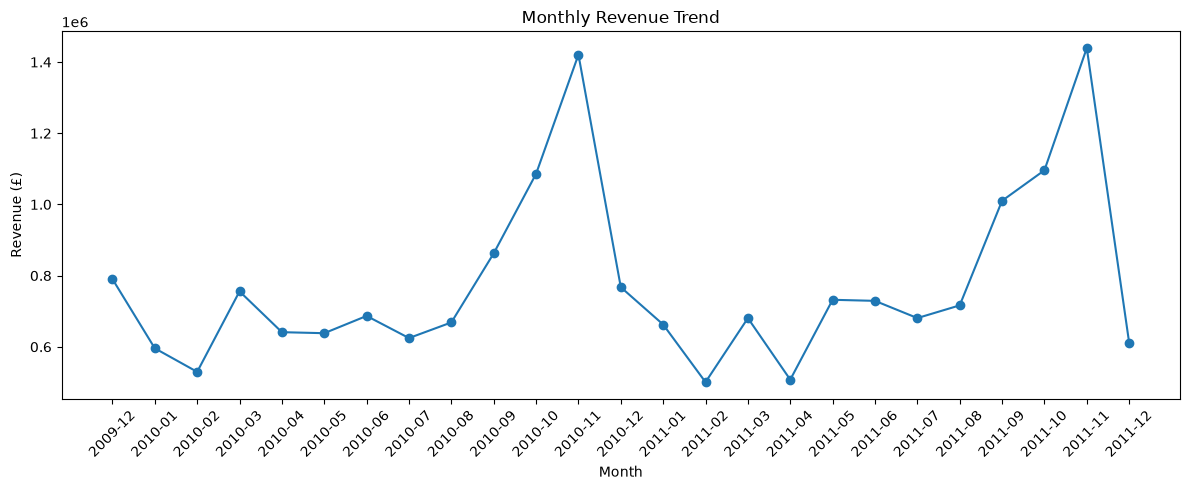

In [85]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["year_month"], monthly_sales["revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Merchandise Dataset for Product Analysis

`DOTCOM` represents a service/postage charge rather than a merchandise product, so it is excluded **only from product-level analysis**.

The original `df_sales` remains unchanged.


In [86]:
non_merchandise_codes = {
    "M",
    "POST",
    "AMAZONFEE",
    "C2",
    "BANK CHARGES",
    "DOT",
    "DOTCOM"
}

non_merchandise_descriptions = {
    "DOTCOM POSTAGE",
    "POSTAGE",
    "BANK CHARGES",
    "AMAZON FEE",
    "MANUAL"
}

stockcode_mask = (
    df_sales["stockcode"].astype(str).str.upper().isin(non_merchandise_codes)
)

description_mask = (
    df_sales["description"]
    .fillna("")
    .astype(str)
    .str.upper()
    .isin(non_merchandise_descriptions)
)

merchandise_mask = (
    (df_sales["price"] > 0)
    & ~(stockcode_mask | description_mask)
)
df_merchandise = df_sales.loc[merchandise_mask].copy()

print("Final sales rows:", f"{len(df_sales):,}")
print("Merchandise rows:", f"{len(df_merchandise):,}")
print("Non-merchandise rows excluded:", f"{len(df_sales) - len(df_merchandise):,}")
print("Merchandise revenue:", f"£{df_merchandise['revenue'].sum():,.2f}")


Final sales rows: 993,401
Merchandise rows: 993,401
Non-merchandise rows excluded: 0
Merchandise revenue: £19,433,661.76


In [87]:
print("PYTHON MERCHANDISE DIAGNOSTIC")
print("=" * 45)

print("Rows with price <= 0:", (df_sales["price"] <= 0).sum())
print("Rows with revenue == 0:", (df_sales["revenue"] == 0).sum())

print("\nPADS rows:")
display(
    df_sales.loc[
        df_sales["stockcode"].astype(str).str.upper().eq("PADS"),
        ["invoice", "stockcode", "description", "quantity", "price", "revenue"]
    ]
)

print("\nCurrent merchandise rows:", len(df_merchandise))

PYTHON MERCHANDISE DIAGNOSTIC
Rows with price <= 0: 0
Rows with revenue == 0: 0

PADS rows:


,invoice,stockcode,description,quantity,price,revenue
59191,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
70836,496222,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
73669,496473,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
75666,496643,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
85835,497935,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
92409,498562,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
96135,499056,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
98721,499399,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
117169,501176,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
148300,504332,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00



Current merchandise rows: 993401


In [88]:
# ============================================================
# DIRECT CSV vs df_sales CHECK
# ============================================================

raw_check = pd.read_csv("../data/cleaned_sales.csv")

print("DIRECT CSV CHECK")
print("=" * 45)

print("CSV rows:", f"{len(raw_check):,}")
print("CSV rows with price <= 0:", (raw_check["price"] <= 0).sum())
print(
    "CSV PADS rows:",
    (
        raw_check["stockcode"]
        .astype(str)
        .str.upper()
        .eq("PADS")
    ).sum()
)

print("\nPADS records from CSV:")

display(
    raw_check.loc[
        raw_check["stockcode"]
        .astype(str)
        .str.upper()
        .eq("PADS"),
        ["invoice", "stockcode", "description", "quantity", "price", "revenue"]
    ]
)

DIRECT CSV CHECK
CSV rows: 993,401
CSV rows with price <= 0: 0
CSV PADS rows: 17

PADS records from CSV:


,invoice,stockcode,description,quantity,price,revenue
59191,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
70836,496222,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
73669,496473,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
75666,496643,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
85835,497935,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
92409,498562,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
96135,499056,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
98721,499399,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
117169,501176,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00
148300,504332,PADS,PADS TO MATCH ALL CUSHIONS,1,0.00,0.00


In [89]:
# ============================================================
# COMPARE df_sales WITH AUTHORITATIVE cleaned_sales.csv
# ============================================================

print("DATASET CONSISTENCY CHECK")
print("=" * 50)

# PADS in current df_sales
df_pads = df_sales.loc[
    df_sales["stockcode"]
    .astype(str)
    .str.upper()
    .eq("PADS")
]

# PADS in authoritative CSV
csv_pads = raw_check.loc[
    raw_check["stockcode"]
    .astype(str)
    .str.upper()
    .eq("PADS")
]

print("PADS rows in df_sales:", len(df_pads))
print("PADS rows in CSV:", len(csv_pads))

# Zero-price rows
print()
print("Zero-price rows in df_sales:", (df_sales["price"] <= 0).sum())
print("Zero-price rows in CSV:", (raw_check["price"] <= 0).sum())

# Check DOTCOM
print()
print(
    "DOTCOM rows in df_sales:",
    df_sales["stockcode"].astype(str).str.upper().eq("DOTCOM").sum()
)

print(
    "DOTCOM rows in CSV:",
    raw_check["stockcode"].astype(str).str.upper().eq("DOTCOM").sum()
)

# Compare total revenue
print()
print(
    "df_sales revenue:",
    f"£{df_sales['revenue'].sum():,.2f}"
)

print(
    "CSV revenue:",
    f"£{raw_check['revenue'].sum():,.2f}"
)

DATASET CONSISTENCY CHECK
PADS rows in df_sales: 17
PADS rows in CSV: 17

Zero-price rows in df_sales: 0
Zero-price rows in CSV: 0

DOTCOM rows in df_sales: 0
DOTCOM rows in CSV: 0

df_sales revenue: £19,433,661.76
CSV revenue: £19,433,661.76


In [90]:
# ============================================================
# MERCHANDISE PRICE DIAGNOSTIC
# ============================================================

print("PRICE DIAGNOSTIC")
print("=" * 50)

print("Rows with price <= 0:",
      f"{(df_sales['price'] <= 0).sum():,}")

print("Minimum price:",
      df_sales["price"].min())

print("Maximum price:",
      df_sales["price"].max())

print("Missing prices:",
      f"{df_sales['price'].isna().sum():,}")

print("\nPrice distribution for non-positive prices:")

display(
    df_sales.loc[
        df_sales["price"] <= 0,
        [
            "invoice",
            "stockcode",
            "description",
            "quantity",
            "price",
            "revenue"
        ]
    ].head(25)
)

PRICE DIAGNOSTIC
Rows with price <= 0: 0
Minimum price: 0.001
Maximum price: 1157.15
Missing prices: 0

Price distribution for non-positive prices:


,invoice,stockcode,description,quantity,price,revenue


In [91]:
# ============================================================
# NON-MERCHANDISE DIAGNOSTIC CHECK
# ============================================================

print("Checking possible non-merchandise records...")
print()

print("Stock codes:")

print(
    df_sales[
        df_sales["stockcode"]
        .astype(str)
        .str.upper()
        .isin([
            "M",
            "POST",
            "AMAZONFEE",
            "C2",
            "BANK CHARGES",
            "DOT",
            "DOTCOM"
        ])
    ][["stockcode", "description", "revenue"]]
    .groupby(["stockcode", "description"], dropna=False)
    .agg(
        rows=("revenue", "size"),
        revenue=("revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
)

print()
print("Description matches:")

print(
    df_sales[
        df_sales["description"]
        .fillna("")
        .astype(str)
        .str.upper()
        .isin([
            "DOTCOM POSTAGE",
            "POSTAGE",
            "BANK CHARGES",
            "AMAZON FEE",
            "MANUAL"
        ])
    ][["stockcode", "description", "revenue"]]
    .groupby(["stockcode", "description"], dropna=False)
    .agg(
        rows=("revenue", "size"),
        revenue=("revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
)

Checking possible non-merchandise records...

Stock codes:
Empty DataFrame
Columns: [rows, revenue]
Index: []

Description matches:
Empty DataFrame
Columns: [rows, revenue]
Index: []


## 7. Product Performance — Revenue

In [92]:
product_revenue = (
    df_merchandise.groupby(["stockcode", "description"])
    .agg(
        revenue=("revenue", "sum"),
        units_sold=("quantity", "sum"),
        orders=("invoice", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

product_revenue.head(20)


,stockcode,description,revenue,units_sold,orders,customers
1854,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26478,3918,1314
4915,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94142,5356,1490
3293,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1
3642,47566,PARTY BUNTING,"148,318.28",28200,2674,894
4884,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77280,3245,860
4559,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80082,2807,1010
1450,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",35084,2018,896
2757,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,138
3981,79321,CHILLI LIGHTS,"80,540.88",15841,1135,304
4147,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"71,300.40",31409,756,300


## 8. Top 10 Products by Revenue

In [93]:
top_10_products_revenue = product_revenue.head(10).copy()
top_10_products_revenue


,stockcode,description,revenue,units_sold,orders,customers
1854,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26478,3918,1314
4915,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94142,5356,1490
3293,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1
3642,47566,PARTY BUNTING,"148,318.28",28200,2674,894
4884,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77280,3245,860
4559,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80082,2807,1010
1450,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",35084,2018,896
2757,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,138
3981,79321,CHILLI LIGHTS,"80,540.88",15841,1135,304
4147,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"71,300.40",31409,756,300


## 9. Top 10 Products by Units Sold

In [94]:
top_10_products_units = (
    product_revenue
    .sort_values("units_sold", ascending=False)
    .head(10)
    .copy()
)

top_10_products_units


,stockcode,description,revenue,units_sold,orders,customers
4092,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"24,445.61",106139,1019,482
4915,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94142,5356,1490
3293,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1
4559,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80082,2807,1010
2757,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,138
4884,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77280,3245,860
120,17003,BROCADE RING PURSE,"14,766.42",70369,456,215
1359,21977,PACK OF 60 PINK PAISLEY CAKE CASES,"28,081.73",56061,1993,767
4718,84991,60 TEATIME FAIRY CAKE CASES,"27,041.21",54028,2127,822
1578,22197,SMALL POPCORN HOLDER,"42,699.89",48561,1407,426


## 10. Average Selling Price by Product

In [95]:
product_revenue["avg_selling_price"] = (
    product_revenue["revenue"] / product_revenue["units_sold"]
)

product_revenue.head(20)


,stockcode,description,revenue,units_sold,orders,customers,avg_selling_price
1854,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26478,3918,1314,12.49
4915,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94142,5356,1490,2.74
3293,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,2.08
3642,47566,PARTY BUNTING,"148,318.28",28200,2674,894,5.26
4884,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77280,3245,860,1.89
4559,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80082,2807,1010,1.61
1450,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",35084,2018,896,3.36
2757,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,138,1.05
3981,79321,CHILLI LIGHTS,"80,540.88",15841,1135,304,5.08
4147,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"71,300.40",31409,756,300,2.27


## 11. Geographic Sales Analysis

In [96]:
country_sales = (
    df_sales.groupby("country")
    .agg(
        revenue=("revenue", "sum"),
        orders=("invoice", "nunique"),
        units=("quantity", "sum"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

country_sales["revenue_share_pct"] = (
    country_sales["revenue"] / country_sales["revenue"].sum() * 100
).round(2)

country_sales.head(20)


,country,revenue,orders,units,customers,revenue_share_pct
40,United Kingdom,"16,622,106.95",36164,9099055,5334,85.53
11,EIRE,"616,310.90",580,332965,3,3.17
26,Netherlands,"546,880.56",216,382502,22,2.81
15,Germany,"378,012.16",751,220781,107,1.95
14,France,"307,195.76",598,268880,93,1.58
0,Australia,"165,453.26",89,103084,15,0.85
34,Spain,"97,280.46",144,49699,38,0.50
36,Switzerland,"93,231.03",85,52232,22,0.48
35,Sweden,"84,798.44",99,88029,19,0.44
10,Denmark,"67,276.89",42,237322,12,0.35


## 12. Sales by Day of Week

In [97]:
weekday_sales = (
    df_sales.assign(day_of_week=df_sales["invoicedate"].dt.day_name())
    .groupby("day_of_week")
    .agg(
        revenue=("revenue", "sum"),
        orders=("invoice", "nunique"),
        units=("quantity", "sum")
    )
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
    .reset_index()
)

weekday_sales


,day_of_week,revenue,orders,units
0,Monday,"3,386,288.94",6243,2015703
1,Tuesday,"3,827,221.27",7140,2117879
2,Wednesday,"3,334,998.04",7110,1978461
3,Thursday,"3,971,980.11",8162,2298920
4,Friday,"3,134,545.15",5987,1662605
5,Saturday,"9,708.85",30,5047
6,Sunday,"1,768,919.39",4820,1019011


## 13. Sales by Hour

In [98]:
hourly_sales = (
    df_sales.assign(hour=df_sales["invoicedate"].dt.hour)
    .groupby("hour")
    .agg(
        revenue=("revenue", "sum"),
        orders=("invoice", "nunique"),
        units=("quantity", "sum")
    )
    .reset_index()
    .sort_values("hour")
)

hourly_sales


,hour,revenue,orders,units
0,6,4.25,1,1
1,7,"73,541.24",76,44112
2,8,"517,435.29",996,293498
3,9,"1,690,076.00",2721,911047
4,10,"2,480,872.91",4561,1475390
5,11,"2,395,244.15",4836,1434650
6,12,"2,757,906.42",6363,1650767
7,13,"2,454,859.60",5637,1538570
8,14,"2,190,160.31",4969,1175991
9,15,"2,206,580.88",4481,1229124


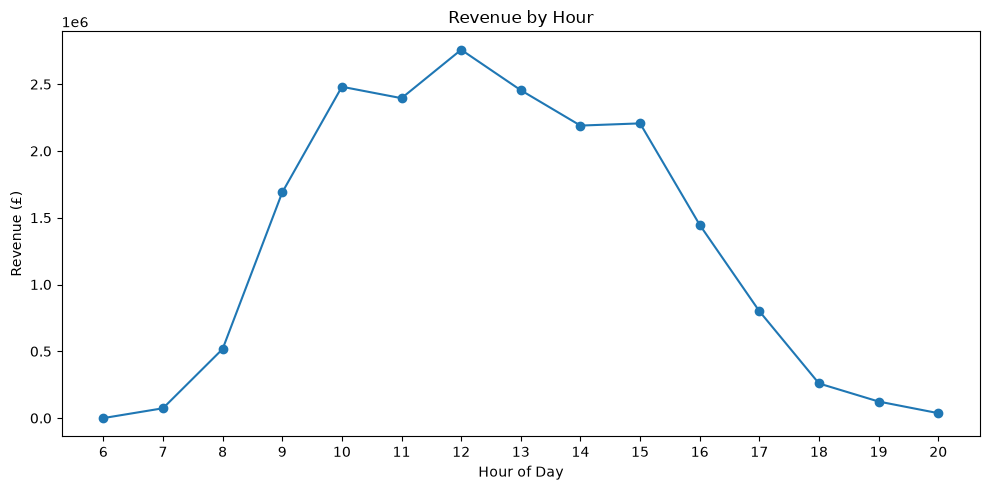

In [99]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_sales["hour"], hourly_sales["revenue"], marker="o")
plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue (£)")
plt.xticks(hourly_sales["hour"])
plt.tight_layout()
plt.show()


## 14. Best Sales Month

In [100]:
best_month = monthly_sales.loc[monthly_sales["revenue"].idxmax()]

print("Best sales month:", best_month["year_month"])
print("Revenue:", f"£{best_month['revenue']:,.2f}")
print("Orders:", f"{best_month['orders']:,}")


Best sales month: 2011-11
Revenue: £1,439,365.64
Orders: 2,750


## 15. Top Product

In [101]:
best_product = product_revenue.iloc[0]

print("Top product:", best_product["description"])
print("Stock code:", best_product["stockcode"])
print("Revenue:", f"£{best_product['revenue']:,.2f}")
print("Units sold:", f"{best_product['units_sold']:,.0f}")
print("Orders:", f"{best_product['orders']:,.0f}")


Top product: REGENCY CAKESTAND 3 TIER
Stock code: 22423
Revenue: £330,590.32
Units sold: 26,478
Orders: 3,918


In [102]:
# ============================================================
# TOP PRODUCT VALIDATION
# ============================================================

top_product_code = best_product["stockcode"]

top_product_transactions = df_merchandise[
    df_merchandise["stockcode"] == top_product_code
].copy()

print("TOP PRODUCT VALIDATION")
print("=" * 45)
print("Product:", best_product["description"])
print("Stock code:", top_product_code)
print("Rows:", f"{len(top_product_transactions):,}")
print("Orders:", f"{top_product_transactions['invoice'].nunique():,}")
print("Customers:", f"{top_product_transactions['customer_id'].nunique():,}")
print("Units:", f"{top_product_transactions['quantity'].sum():,}")
print("Revenue:", f"£{top_product_transactions['revenue'].sum():,.2f}")

print("\nTransaction details:")
display(
    top_product_transactions[
        [
            "invoice",
            "invoicedate",
            "quantity",
            "price",
            "customer_id",
            "country",
            "revenue"
        ]
    ]
)

TOP PRODUCT VALIDATION
Product: REGENCY CAKESTAND 3 TIER
Stock code: 22423
Rows: 3,950
Orders: 3,918
Customers: 1,314
Units: 26,478
Revenue: £330,590.32

Transaction details:


,invoice,invoicedate,quantity,price,customer_id,country,revenue
117441,501276,2010-03-15 13:55:00,8,12.75,"18,135.00",United Kingdom,102.00
118482,501320,2010-03-16 09:49:00,8,12.75,"15,123.00",United Kingdom,102.00
118494,501345,2010-03-16 10:49:00,8,12.75,"15,946.00",United Kingdom,102.00
118645,501422,2010-03-16 11:53:00,1,12.75,"14,146.00",United Kingdom,12.75
118826,501434,2010-03-16 13:15:00,1,12.75,"14,496.00",United Kingdom,12.75
...,...,...,...,...,...,...,...
991150,581439,2011-12-08 16:30:00,3,24.96,NaN,United Kingdom,74.88
991446,581449,2011-12-08 17:37:00,1,12.75,"12,748.00",United Kingdom,12.75
991745,581472,2011-12-08 19:55:00,2,12.75,"15,796.00",United Kingdom,25.50
992779,581495,2011-12-09 10:20:00,10,12.75,"14,051.00",United Kingdom,127.50


## 16. Management Summary

In [103]:
management_summary = {
    "Total Revenue": df_sales["revenue"].sum(),
    "Total Orders": df_sales["invoice"].nunique(),
    "Total Units Sold": df_sales["quantity"].sum(),
    "Unique Products": df_merchandise["stockcode"].nunique(),
    "Identified Customers": df_sales["customer_id"].nunique(),
    "Average Order Value": df_sales["revenue"].sum() / df_sales["invoice"].nunique(),
    "Top Product": best_product["description"],
    "Top Product Revenue": best_product["revenue"],
    "Best Sales Month": best_month["year_month"],
    "Best Month Revenue": best_month["revenue"],
    "Top Country": country_sales.iloc[0]["country"],
    "Top Country Revenue": country_sales.iloc[0]["revenue"]
}

management_summary


{'Total Revenue': np.float64(19433661.757000003),
 'Total Orders': 39492,
 'Total Units Sold': np.int64(11097626),
 'Unique Products': 4855,
 'Identified Customers': 5851,
 'Average Order Value': np.float64(492.0911009065128),
 'Top Product': 'REGENCY CAKESTAND 3 TIER',
 'Top Product Revenue': np.float64(330590.32),
 'Best Sales Month': '2011-11',
 'Best Month Revenue': np.float64(1439365.64),
 'Top Country': 'United Kingdom',
 'Top Country Revenue': np.float64(16622106.946)}

## 17. Final Consistency Check

This final check confirms that the notebook still uses the authoritative transaction dataset and that product analysis does not modify it.


In [104]:
print("FINAL CONSISTENCY CHECK")
print("=" * 45)
print("Transaction rows:", f"{len(df_sales):,}")
print("Transaction revenue:", f"£{df_sales['revenue'].sum():,.2f}")
print("Orders:", f"{df_sales['invoice'].nunique():,}")
print("Units:", f"{df_sales['quantity'].sum():,}")
print("Identified customers:", f"{df_sales['customer_id'].nunique():,}")
print("Merchandise rows:", f"{len(df_merchandise):,}")
print("Merchandise revenue:", f"£{df_merchandise['revenue'].sum():,.2f}")
print("df_sales unchanged:", len(df_sales) == 993401)


FINAL CONSISTENCY CHECK
Transaction rows: 993,401
Transaction revenue: £19,433,661.76
Orders: 39,492
Units: 11,097,626
Identified customers: 5,851
Merchandise rows: 993,401
Merchandise revenue: £19,433,661.76
df_sales unchanged: True
